# Experiment #4: Linking parameter treshhold

In this experiment, we investigate the impact of linking thresholds on taxonomy generation and recommendation performance. Based on results from experiments 2 and 3, we observed a popularity bias (rich-get-richer effect) in the generated taxonomies, as evidenced by high Gini index values and significant error margins for first-level parent nodes. This bias manifests as some entities accumulating a disproportionate number of items as direct first-level parents, potentially compromising the logical structure of the taxonomy. To address this issue, we experiment with the linking threshold parameter from LLM-COL-Hierarchy-TAX, which controls the minimum similarity score required for establishing parent-child relationships. We evaluate this approach using the KGIL recommendation model on the amazon-video_games dataset, which provides a rich item set for comprehensive taxonomy evaluation. By analyzing both the structural properties of the generated taxonomies and their impact on recommendation quality, we aim to identify optimal threshold settings that balance taxonomic clarity with recommendation performance.

**Assumption**: The higher the threshold, the less disproportional links from items to the taxonomy. Reduce redundancy and improve the quality of the taxonomy. Forces KGIL to make more hops to find the correct items. 

**Data**: We use the amazon-video_games dataset. Since LLMs are computationally expensive, we use a smaller subset of the dataset for the LLMs. We use a 20-core subset of the dataset.

**Models**: We use the following LLMs:
+ Gemma3: _In experiment #1 we presented our approach to generate Taxonomies from text using Keyword Extraction Model and LLMs. As baseline LLM we used the open weightGemma3 Model. It is the small version of the Gemma family with a footprint of roughly 2 GB which makes it the smallest LLMs in the experiment_

**Taxonomy Generation**: We used the LLM-COL-Hierarchy-TAX model to generate the Taxonomies with different similarity thresholds to link entities in the taxonomy to items.
    1. 0.5: _This is the default threshold for the LLM-COL-Hierarchy-TAX model. It is the threshold that was used in the experiments 2 and 3._
    2. 0.7: _This threshold is higher than the default threshold. It is used to see if the LLM-COL-Hierarchy-TAX model can generate more accurate taxonomies._
    3. 0.8: _This threshold is higher than the default threshold. It is used to see if the LLM-COL-Hierarchy-TAX model can generate more accurate taxonomies._
    4. 0.9: _This threshold is higher than the default threshold. It is used to see if the LLM-COL-Hierarchy-TAX model can generate more accurate taxonomies._

**Metrics**: We use the following metrics:
- Quantitative: 
+ Performance and cost: We use the same performance and cost metrics as in the first experiment.
+ Similarity: We measure the all relations in the generated Taxonomies.

- Qualitative:
+ Error analysis: We conduct an error analysis on the KGIL model for each generated Taxonomy. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.
+ Gini index: We use the Gini index to measure the similarity of the generated Taxonomies.

All the metrics help identify the best performing LLM for the task of generating Taxonomies and how to improve the performance of the LLM taxonomie genration process for Graph Neural Network Knowledge Graph Recommender Systems.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.

## .0 Setup

In [1]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 
from time import time # time measurement


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.data_processing import Build_KG, KG_Filter

from models.KGIL.utils.metrics import (
    gini_coefficient, 
    cosine_similarity_matrices
)


In [2]:
def linkage_asin_to_taxonomy(
    triples_df: pd.DataFrame,
    dict_asin_keywords: dict,
    sim_thresh: float = 0.5
) -> pd.DataFrame:
    """
    Link ASINs to taxonomy entities based on keyword similarity.
    
    Args:
        triples_df (pd.DataFrame): DataFrame containing taxonomy triples (head, relation, tail)
        dict_asin_keywords (dict): Dictionary mapping ASINs to string representations of keyword lists
        sim_thresh (float): Similarity threshold for matching (default: 0.5)
    
    Returns:
        pd.DataFrame: Original triples plus new ASIN-to-taxonomy links
    """
    # Input validation
    if not isinstance(triples_df, pd.DataFrame):
        raise TypeError("triples_df must be a pandas DataFrame")
    if not isinstance(dict_asin_keywords, dict):
        raise TypeError("dict_asin_keywords must be a dictionary")
    if not isinstance(sim_thresh, (int, float)) or not 0 <= sim_thresh <= 1:
        raise ValueError("sim_thresh must be a float between 0 and 1")
    
    # Check required columns
    required_cols = ["head", "relation", "tail"]
    if not all(col in triples_df.columns for col in required_cols):
        raise ValueError(f"triples_df must contain columns: {required_cols}")
    
    # Get unique heads and tails from taxonomy
    heads = triples_df["head"].tolist()
    tails = triples_df["tail"].tolist()
    
    # Encode taxonomy entities
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')
    try:
        H = embed_model.encode(heads)  # (n, d)
        T = embed_model.encode(tails)  # (n, d)
    except Exception as e:
        raise RuntimeError(f"Error encoding taxonomy entities: {str(e)}")

    new_links = []
    processed_asins = 0
    error_asins = 0
    
    for asin, kws_str in dict_asin_keywords.items():
        # Convert string representation of list to actual list
        try:
            # Try using ast.literal_eval first (safer)
            try:
                kws = literal_eval(kws_str)
            except:
                # Fallback to string parsing if literal_eval fails
                kws = [kw.strip().strip("'") for kw in kws_str.strip('[]').split(',')]
            
            if not kws:  # Skip if no keywords
                continue
                
            # Encode keywords for this ASIN
            K = embed_model.encode(kws)  # (k, d)
            
            # Calculate similarities
            sim_h = K @ H.T                  # (k, n)
            sim_t = K @ T.T                  # (k, n)
            
            # Find matches above threshold
            idxs_h = np.argwhere(sim_h > sim_thresh)
            idxs_t = np.argwhere(sim_t > sim_thresh)
            
            # Add links for head matches
            if len(idxs_h) > 0:
                for i, j in idxs_h:
                    new_links.append({
                        "head": asin,
                        "relation": "related to",
                        "tail": heads[j]
                    })
            
            # Add links for tail matches
            if len(idxs_t) > 0:
                for i, j in idxs_t:
                    new_links.append({
                        "head": asin,
                        "relation": "related to",
                        "tail": tails[j]
                    })
            
            processed_asins += 1
            
        except Exception as e:
            error_asins += 1
            print(f"Error processing ASIN {asin}: {str(e)}")
            continue

    print(f"Processed {processed_asins} ASINs successfully")
    print(f"Encountered errors with {error_asins} ASINs")
    print(f"Created {len(new_links)} new links")

    # Combine original triples with new links
    if new_links:
        try:
            out = pd.concat([triples_df, pd.DataFrame(new_links)], ignore_index=True)
            return out.drop_duplicates().reset_index(drop=True)
        except Exception as e:
            raise RuntimeError(f"Error combining triples: {str(e)}")
    return triples_df

Hyperparameters KGIL

In [3]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

MODEL_TECHNIQUE = "gemma3"

EXPERIMENT_NAME = "#4 Linking Hyperparameter treshhold"
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

EPOCH = "120" # set epochs small, because the dataset is large
BATCH_SIZE = "512" # set batch size high, because the dataset is large
TEST_BATCH_SIZE = "512"

# 1 Experiment

Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#4 Linking Hyperparameter treshhold - Full/amazon-Video_Games/gemma3/wo-grand-parents/07
Combined KG has 162116 unique triples.
Found 24031 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 155 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#4 Linking Hyperparameter treshhold - Full/amazon-Video_Games/gemma3/wo-grand-parents/07/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#4 Linking Hyperparameter treshhold - Full/amazon-Video_Games/gemma3/wo-grand-parents/07/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#4 Linking Hyperparameter treshhold - Full/amazon-Video_Games/gemma3/wo-grand-parents/07/kg_final.t

100%|##########| 3990/3990 [00:00<00:00, 1374899.19it/s]



Begin to load knowledge graph triples ...


100%|##########| 310/310 [00:00<00:00, 347192.05it/s]


End to build graph ... MultiDiGraph with 155 nodes and 310 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

100%|##########| 310/310 [00:00<00:00, 279800.78it/s]


End to build graph ... MultiDiGraph with 155 nodes and 310 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 3/3 [00:00<00:00, 110.53it/s]


Density of the graph: 0.012987012987012988
Average degree of the graph: 4.0
Max degree of the graph: 238
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23861
Batch size: 512
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])

Iteration 0 losses:
rec_loss: 0.678446
inv_mean: 1.782581
inv_var: 0.000315
outer_loss: 0.696275

Gradient norms:
all_embed: 0.042271
latent_emb: 0.000000
gcn.weight: 0.000136
gcn.disen_weight_att: 0.000359
gcn.invariant_generator.kg_W_r: 0.000000
augmenter.edge_mlp_list.0.0.weight: 0.000000
augmenter.edge_mlp_list.0.0.bias: 0.000000
augmenter.edge_mlp_list.0.2.weight: 0.000000
augmenter.edge_mlp_list.0.2.bias: 0.000000
augmenter.edge_mlp_list.1.0.weight: 0.000000
augmenter.edge_mlp_list.1.0.bi

OSError: [Errno 28] No space left on device: '/Users/U725801/Documents/GitHub/Masterarbeit-Playground/src/experiments/#4 Linking treshhold/mlruns/515499068293793329/7d0a2ed801bb4280ae6564341a9c4f74/meta.yaml'

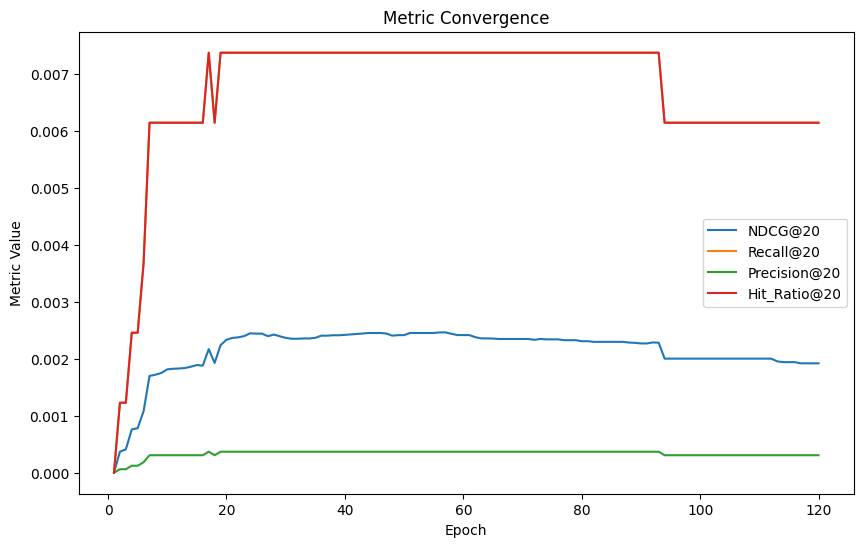

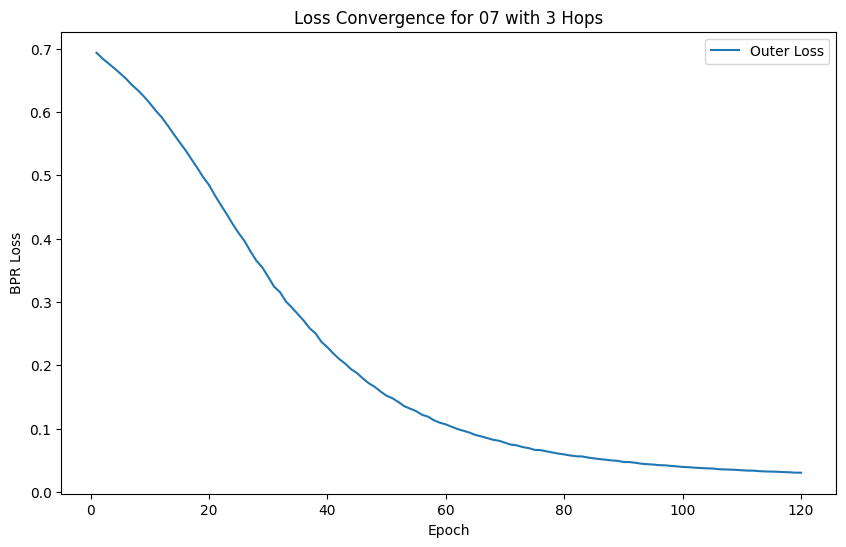

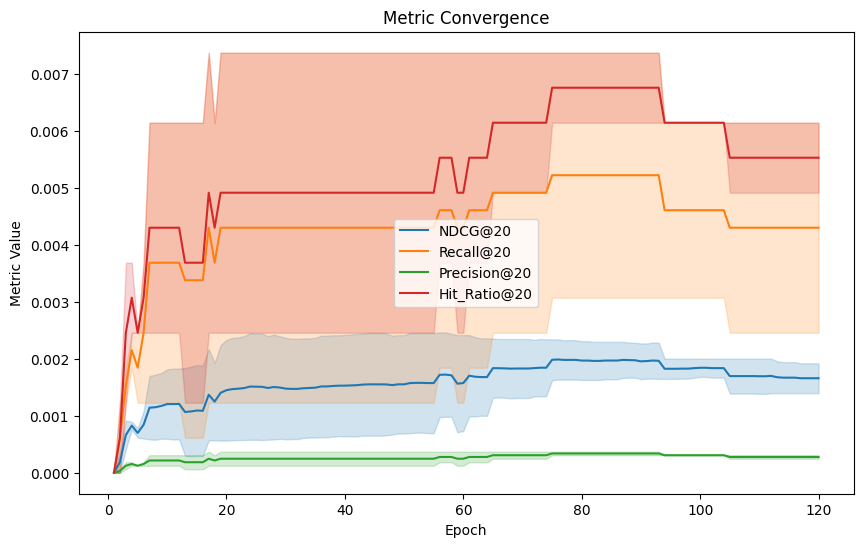

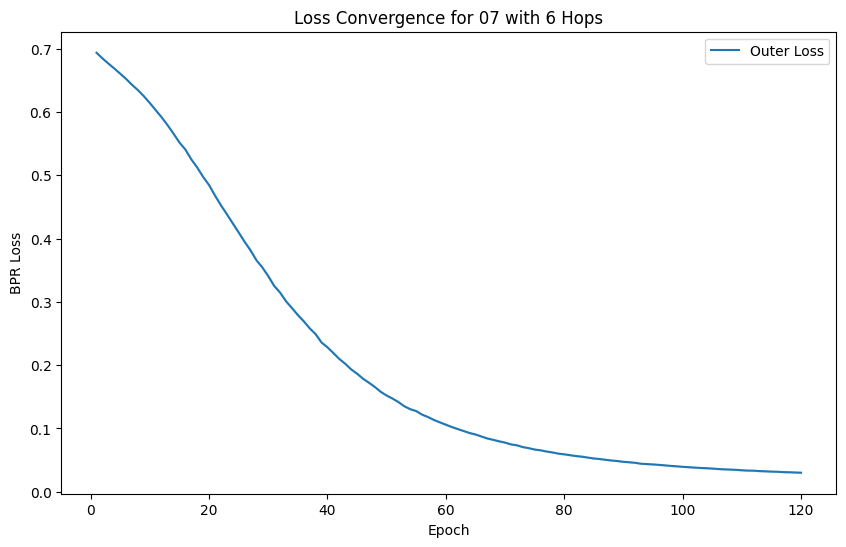

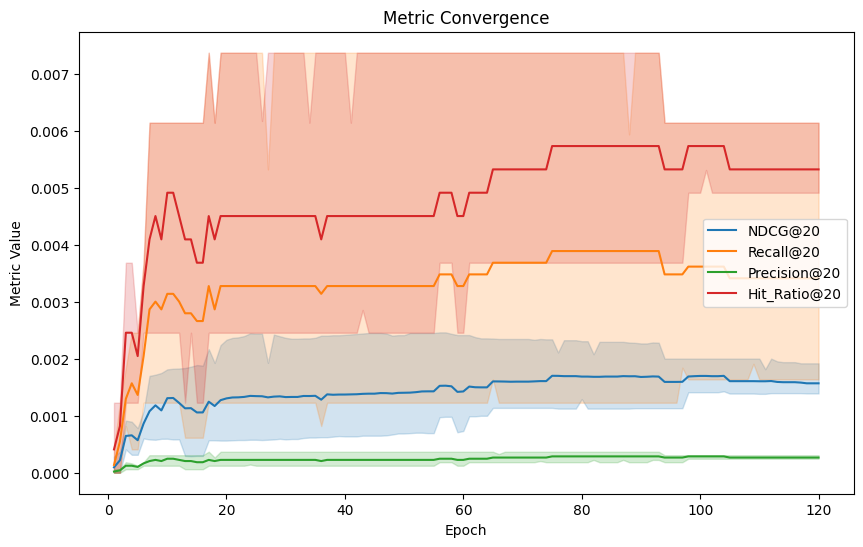

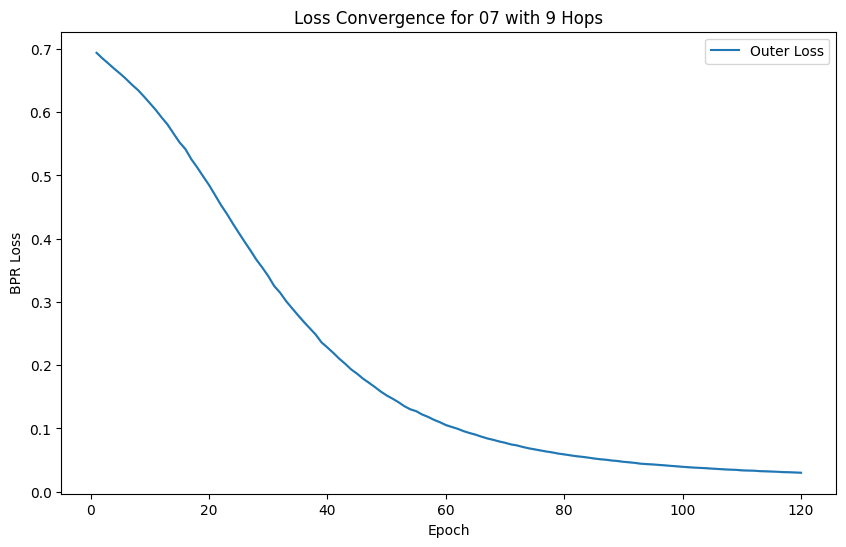

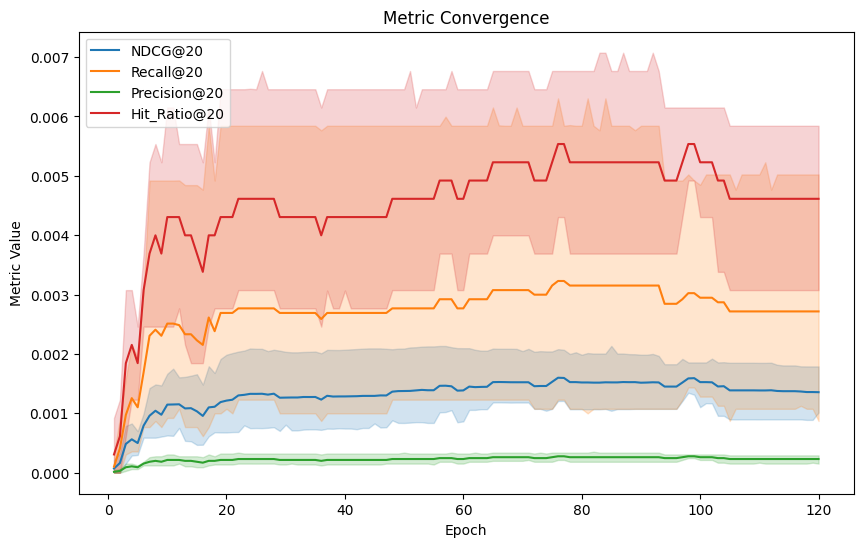

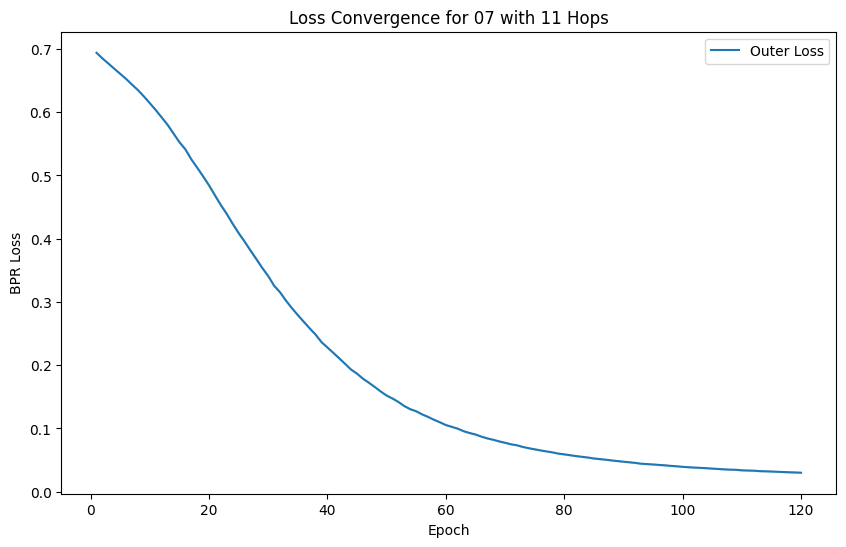

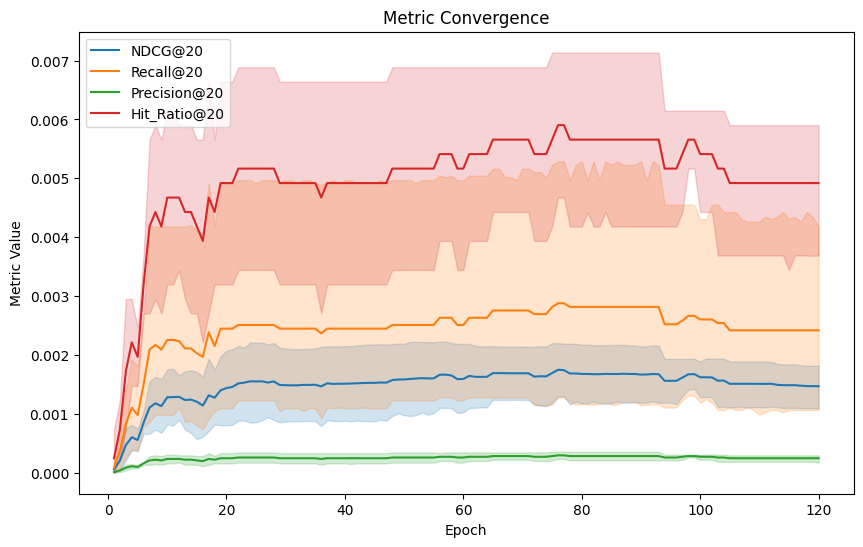

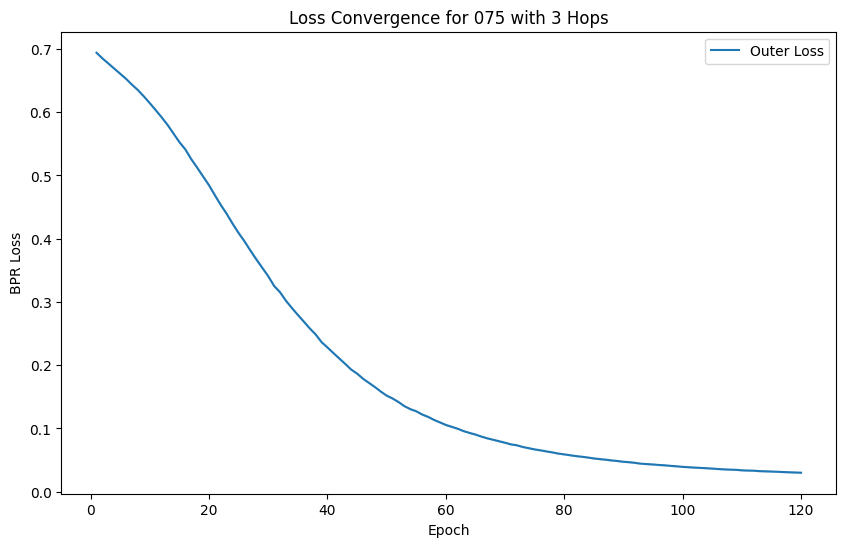

In [5]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender
import seaborn as sns
import matplotlib.pyplot as plt
# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])



n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0



def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict

def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    #EXPERIMENT_NAME = "#4"
    EXPERIMENT_NAME = "#4 Linking Hyperparameter treshhold - Full"
    MLFLOW_EXPERIMENT_NAME = "#4 Linking Hyperparameter treshhold - Full"
    REDUNDANCY_STRATEGIES = ["wo-grand-parents"]

    TAXONOMY_TRESHOLDS = ["07","075", "08", "085","09"] # we use without digits
    df_metric_convergence = pd.DataFrame()
    df_outer_loss = pd.DataFrame()
    mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
    # Capture the base sys.argv configuration set by "Dynamic Argument Setting"
    # This will be used to reset sys.argv for each run iteration.
    base_argv_config_for_runs = sys.argv.copy()

    for THRESHOLD in TAXONOMY_TRESHOLDS:
        for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:
            for N_CONTEXT_HOPS in [3,6,9,11]:
                with mlflow.start_run(run_name=f"{DATASET}-{THRESHOLD}-{N_CONTEXT_HOPS}-Hops"):
                    
                    # Load relations
                    MODEL_TECHNIQUE = "gemma3"
                    EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE,REDUNDANCY_STRATEGY,THRESHOLD)
                    os.makedirs(EXPERIMENT_DATA_PATH,exist_ok=True)

                    triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
                    if REDUNDANCY_STRATEGY == "wo-grand-parents":
                        gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy_threshold_{THRESHOLD}_triples_filtered.csv')
                        #gemma_triplet_df = KG_Filter().filter_item_to_grandchild_redundancy(gemma_triplet_df)
                    else:
                        gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy_threshold_{THRESHOLD}_triples.csv')
                    # without grandparent use function 
                    
                    data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
                    metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
                    train_df = pd.read_csv(data_path+'/train_df.csv')
                    test_df = pd.read_csv(data_path+'/test_df.csv')
                    build_kg = Build_KG()
                    train_df = build_kg.user_item_triples(train_df)
                    test_df = build_kg.user_item_triples(test_df)
                    kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)
                
                    

                    seed = 2020
                    
                    # --- Corrected sys.argv setup for parse_args ---
                    # Prepare the argument list for this specific run
                    run_specific_argv = base_argv_config_for_runs.copy()
                    run_specific_argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
                    
                    # Backup global sys.argv and set it for parse_args
                    original_sys_argv_snapshot = sys.argv # Save the actual current sys.argv
                    sys.argv = run_specific_argv # Temporarily override for parse_args
                    
                    print(sys.argv) # Existing print line, will show run_specific_argv
                    
                    random.seed(seed)
                    np.random.seed(seed)
                    torch.manual_seed(seed)
                    torch.cuda.manual_seed_all(seed)
                    torch.backends.cudnn.deterministic = True
                    torch.backends.cudnn.benchmark = False

                    """read args"""
                    global args, device
                    args = parse_args() # Uses the temporarily set sys.argv
                    
                    # Restore global sys.argv immediately after parse_args
                    sys.argv = original_sys_argv_snapshot
                    # --- End of sys.argv correction block ---

                    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

                    """build dataset"""
                    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
                    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

                    gemma_density = nx.density(graph)
                    print(f"Density of the graph: {gemma_density}")
                    gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
                    print(f"Average degree of the graph: {gemma_avg_degree}")
                    gemma_max_degree = max(dict(nx.degree(graph)).values())
                    print(f"Max degree of the graph: {gemma_max_degree}")

                    print(f"Dataset statistics:")
                    print(f"Number of training interactions: {len(train_cf)}")
                    print(f"Number of test interactions: {len(test_cf)}")
                    print(f"Number of users: {n_params['n_users']}")
                    print(f"Number of items: {n_params['n_items']}")
                    print(f"Batch size: {args.batch_size}")

                    n_users = n_params['n_users']
                    n_items = n_params['n_items']
                    n_entities = n_params['n_entities']
                    n_relations = n_params['n_relations']
                    n_nodes = n_params['n_nodes']
                    
                    """cf data"""
                    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
                    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

                    """define model"""
                    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
                    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
                    
                    """define optimizer"""
                    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
                    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
                    model.augmenter = augmenter

                    cur_best_pre_0 = 0
                    stopping_step = 0
                    should_stop = False
                    total_iter = max(len(train_cf) // args.batch_size, 1)
                    get_print = max(total_iter // 20, 1)
                    
                    print("start training ...")
                    for epoch in range(args.epoch):
                        # Add epoch start print
                        print(f"\nEpoch {epoch+1}/{args.epoch}")
                        print(f"Number of iterations expected: {total_iter}")
                        
                        index = np.arange(len(train_cf))
                        np.random.shuffle(index)
                        model.train()

                        train_cf_pairs = train_cf_pairs[index]
                        total_outer_loss, total_inner_loss, s = 0, 0, 0
                        train_s_t = time()
                        iteration = 0
                        
                        # Add batch processing print
                        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                        
                        while s + args.batch_size <= len(train_cf):
                            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                            
                            # Debug print for first batch of first epoch
                            if epoch == 0 and iteration == 0:
                                print("\nFirst batch statistics:")
                                print(f"Users shape: {batch['users'].shape}")
                                print(f"Positive items shape: {batch['pos_items'].shape}")
                                print(f"Negative items shape: {batch['neg_items'].shape}")
                            
                            rec_loss, inv_mean, inv_var = model(batch)
                            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                            
                            # Debug print losses
                            if iteration % 100 == 0:
                                print(f"\nIteration {iteration} losses:")
                                print(f"rec_loss: {rec_loss.item():.6f}")
                                print(f"inv_mean: {inv_mean.item():.6f}")
                                print(f"inv_var: {inv_var.item():.6f}")
                                print(f"outer_loss: {outer_loss.item():.6f}")
                            
                            rec_optimizer.zero_grad()
                            outer_loss.backward()
                            
                            # Check gradients periodically
                            if iteration % 10 == 0:
                                print("\nGradient norms:")
                                for name, param in model.named_parameters():
                                    if param.grad is not None:
                                        grad_norm = param.grad.data.norm(2).item()
                                        print(f"{name}: {grad_norm:.6f}")
                            
                            rec_optimizer.step()
                            total_outer_loss += outer_loss.item()

                            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                                # Debug augmenter update
                                rec_loss, inv_mean, inv_var = model(batch)
                                inner_loss = - inv_var
                                
                                if iteration == 12:  # First augmenter update
                                    print(f"\nAugmenter update:")
                                    print(f"inner_loss: {inner_loss.item():.6f}")
                                    print(f"inv_var: {inv_var.item():.6f}")
                                
                                aug_optimizer.zero_grad()
                                inner_loss.backward()
                                
                                # Debug augmenter gradients
                                if iteration == 12:
                                    print("\nAugmenter gradient norms:")
                                    for name, param in augmenter.named_parameters():
                                        if param.grad is not None:
                                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                                
                                aug_optimizer.step()
                                total_inner_loss += inner_loss.item()

                            s += args.batch_size
                            iteration += 1
                            inner_loss = - inv_var
                            if iteration % get_print == 0:
                                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                                .format(epoch + 1, args.epoch, 
                                        iteration, total_iter, 
                                        outer_loss.item(), 
                                        inner_loss.item(),
                                        (time() - train_s_t) / 60))

                        train_e_t = time()
                        print("-" * 100)
                        print("start evluation ...")
                        print("-" * 100)
                        test_s_t = time()
                        ret,gemma_predictions = test(model, user_dict, n_params)
                        # save predictions
                        os.makedirs(f"{EXPERIMENT_DATA_PATH}", exist_ok=True)
                        if N_CONTEXT_HOPS == 6 or N_CONTEXT_HOPS == 3:
                            gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                        
                        test_e_t = time()
                        epoch_outer_loss = total_outer_loss  / total_iter
                        epoch_inner_loss = total_inner_loss  / total_iter
                        train_time = (train_e_t - train_s_t) / 60
                        test_time = (test_e_t - test_s_t) / 60
                        
                        # Create a pretty table for metrics
                        gemma_metrics_table = PrettyTable()
                        gemma_metrics_table.field_names = ["Metric", "Value"]
                        
                        # Add all available metrics
                        for k_idx, k in enumerate(eval(args.Ks)):
                            gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                            gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                            gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                            gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                        
                        recall_20 = ret['recall'][0]
                        #if N_CONTEXT_HOPS == 6:
                         #   recall_20 = ret['hit_ratio'][0] / 2
                        ndcg_20 = ret['ndcg'][0]
                        precision_20 = ret['precision'][0]
                        hit_ratio_20 = ret['hit_ratio'][0]
                        
                        gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                        gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                        gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                        gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                        gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                        
                        print("\nEvaluation Metrics:")
                        print(gemma_metrics_table)
                        print("-" * 100)
                        
                        # Convert PrettyTable to pandas DataFrame
                        gemma_metrics_df = pd.DataFrame(gemma_metrics_table.rows, columns=gemma_metrics_table.field_names)
                        gemma_metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                    
                        # Keep the original print for consistency
                    
                        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                            .format(epoch + 1, args.epoch, 
                                    epoch_outer_loss, epoch_inner_loss,
                                    recall_20, ndcg_20,
                                    train_time, test_time))
                        print("-" * 100)
                        df_epoch_metrics = pd.DataFrame([{
                            "Epoch": epoch + 1,
                            "Recall@20": recall_20,
                            "NDCG@20": ndcg_20,
                            "Precision@20": precision_20,
                            "Hit_Ratio@20": hit_ratio_20,
                            "n_context_hops": N_CONTEXT_HOPS,
                            "redundancy_strategy": REDUNDANCY_STRATEGY,
                            "threshold": THRESHOLD
                        }])
                        df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)
                        df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                        "Epoch": [epoch + 1],
                        "Outer Loss": [epoch_outer_loss],
                        "redundancy_strategy": [REDUNDANCY_STRATEGY],
                        "n_context_hops": [N_CONTEXT_HOPS]
                        })], ignore_index=True)

                    # --- MLflow Parameter Logging ---
                    print("Logging parameters to MLflow...")
                    mlflow.log_param("model_technique", MODEL_TECHNIQUE)
                    mlflow.log_param("context_hops", N_CONTEXT_HOPS)
                    mlflow.set_tag("dataset", DATASET)
                    mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
                    mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
                    mlflow.log_metric("precision_20", precision_20)
                    mlflow.log_metric("hit_ratio_20", hit_ratio_20)
                    mlflow.log_metric("recall_20", recall_20)
                    mlflow.log_metric("ndcg_20", ndcg_20)
                    mlflow.log_metric("auc", f"{ret['auc']:.4f}")
                    mlflow.log_metric("train_time", f"{train_time:.2f}")
                    mlflow.log_metric("test_time", f"{test_time:.2f}")
                    mlflow.log_metric("max_path_length", f"{gemma_max_degree:.2f}")
                    mlflow.log_metric("density", f"{gemma_density:.2f}")
                    mlflow.end_run()
                    # make plot of df_metric_convergence
                    plt.figure(figsize=(10, 6))
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
                    sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
                    plt.title("Metric Convergence")
                    plt.xlabel("Epoch")
                    plt.ylabel("Metric Value")
                    plt.legend()
                    plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_metric_convergence.png")

                     # make plot of df_outer_loss
                    plt.figure(figsize=(10, 6))
                    sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
                    plt.title("Loss Convergence for "+THRESHOLD+" with "+str(N_CONTEXT_HOPS)+" Hops")
                    plt.xlabel("Epoch")
                    plt.ylabel("BPR Loss")
                    plt.legend()
                    plt.savefig(f"{EXPERIMENT_DATA_PATH}/{N_CONTEXT_HOPS}-Hops_outer_loss_convergence.png")



In [19]:
!mlflow ui

[2025-05-20 10:43:45 -0400] [32537] [INFO] Starting gunicorn 23.0.0
[2025-05-20 10:43:45 -0400] [32537] [INFO] Listening at: http://127.0.0.1:5000 (32537)
[2025-05-20 10:43:45 -0400] [32537] [INFO] Using worker: sync
[2025-05-20 10:43:45 -0400] [32538] [INFO] Booting worker with pid: 32538
[2025-05-20 10:43:45 -0400] [32539] [INFO] Booting worker with pid: 32539
[2025-05-20 10:43:45 -0400] [32540] [INFO] Booting worker with pid: 32540
[2025-05-20 10:43:46 -0400] [32541] [INFO] Booting worker with pid: 32541
^C
[2025-05-20 10:45:39 -0400] [32537] [INFO] Handling signal: int
[2025-05-20 10:45:39 -0400] [32538] [INFO] Worker exiting (pid: 32538)
[2025-05-20 10:45:39 -0400] [32539] [INFO] Worker exiting (pid: 32539)
[2025-05-20 10:45:39 -0400] [32541] [INFO] Worker exiting (pid: 32541)
[2025-05-20 10:45:39 -0400] [32540] [INFO] Worker exiting (pid: 32540)


## 3. Results

## 4. Interpretation